<a href="https://www.kaggle.com/code/parin222/vit-lung-cancer?scriptVersionId=301547830" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [7]:
!pip install timm

In [8]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import matplotlib.pyplot as plt

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

In [9]:
train_dir = "/kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Train and Validation Set"
test_dir  = "/kaggle/input/datasets/javaidahmadwani/lc25000/lung_colon_image_set/Test Set"

In [10]:
selected_classes = ['lung_aca', 'lung_n', 'lung_scc']
num_classes = len(selected_classes)

print("Total number of selected classes:", num_classes)

Total number of selected classes: 3


In [11]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [12]:
# Load full dataset
full_train_dataset = datasets.ImageFolder(train_dir, transform=transform)
full_test_dataset  = datasets.ImageFolder(test_dir, transform=transform)

# Get class indices for lung classes
lung_indices = [full_train_dataset.class_to_idx[c] for c in selected_classes]

def filter_dataset(dataset):
    indices = [i for i, (_, label) in enumerate(dataset) if label in lung_indices]
    return Subset(dataset, indices)

train_dataset = filter_dataset(full_train_dataset)
test_dataset  = filter_dataset(full_test_dataset)

print("Total training images:", len(train_dataset))
print("Total test images:", len(test_dataset))

Total training images: 13501
Total test images: 1499


In [13]:
# Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Load pretrained Vision Transformer
model = timm.create_model('vit_base_patch16_224', pretrained=True)

# Replace classification head (because we have 3 lung classes)
model.head = nn.Linear(model.head.in_features, num_classes)

# Move model to GPU
model = model.to(device)

Using device: cuda


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

In [14]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [15]:
# CrossEntropyLoss is used for multi-class classification
criterion = nn.CrossEntropyLoss()

# Adam optimizer updates model weights
optimizer = optim.Adam(model.parameters(), lr=1e-4)


In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = timm.create_model('vit_base_patch16_224', pretrained=True)

# Replace final classification layer
model.head = nn.Linear(model.head.in_features, num_classes)

model = model.to(device)

In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=3e-5)

In [18]:
# Create mapping from original dataset labels → 0,1,2
lung_indices = [full_train_dataset.class_to_idx[c] for c in selected_classes]

class_map = {}
for new_label, original_label in enumerate(lung_indices):
    class_map[original_label] = new_label

print("Class mapping:", class_map)

Class mapping: {2: 0, 3: 1, 4: 2}


In [19]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0.0001):
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.early_stop = False

    def __call__(self, val_loss, model):

        # Check if validation loss improved
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            
            # Save best model
            torch.save(model.state_dict(), "best_model.pth")
            print("✅ Validation loss improved — model saved")

        else:
            self.counter += 1
            print(f"⚠️ No improvement ({self.counter}/{self.patience})")

            if self.counter >= self.patience:
                self.early_stop = True

In [20]:
early_stopper = EarlyStopping(patience=7)
from tqdm import tqdm


In [21]:
from tqdm import tqdm

epochs = 50

for epoch in range(epochs):

    print(f"\n========== Epoch [{epoch+1}/{epochs}] ==========")

    # ================= TRAINING =================
    model.train()
    train_loss = 0
    train_correct = 0
    train_total = 0

    train_bar = tqdm(train_loader, desc="Training")

    for images, labels in train_bar:
        images = images.to(device)

        # Map labels correctly
        labels = torch.tensor([class_map[l.item()] for l in labels]).to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        train_correct += (preds == labels).sum().item()
        train_total += labels.size(0)

        train_bar.set_postfix(
            loss=train_loss/len(train_loader),
            acc=100*train_correct/train_total
        )

    train_loss /= len(train_loader)
    train_acc = 100 * train_correct / train_total


    # ================= VALIDATION =================
    model.eval()
    val_loss = 0
    val_correct = 0
    val_total = 0

    val_bar = tqdm(test_loader, desc="Validation")

    with torch.no_grad():
        for images, labels in val_bar:
            images = images.to(device)

            labels = torch.tensor([class_map[l.item()] for l in labels]).to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

            val_bar.set_postfix(
                loss=val_loss/len(test_loader),
                acc=100*val_correct/val_total
            )

    val_loss /= len(test_loader)
    val_acc = 100 * val_correct / val_total

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    # ================= EARLY STOPPING =================
    early_stopper(val_loss, model)

    if early_stopper.early_stop:
        print("\n🚨 Early stopping triggered!")
        break

model.load_state_dict(torch.load("best_model.pth"))
print("✅ Best model loaded successfully")


========== Epoch [1/50] ==========


Validation: 100%|██████████| 47/47 [00:20<00:00,  2.26it/s, acc=99.3, loss=0.0202] 



Train Loss: 0.0921 | Train Acc: 96.50%
Val   Loss: 0.0202 | Val   Acc: 99.33%
✅ Validation loss improved — model saved

========== Epoch [2/50] ==========


Validation: 100%|██████████| 47/47 [00:20<00:00,  2.29it/s, acc=99, loss=0.0218]   



Train Loss: 0.0179 | Train Acc: 99.35%
Val   Loss: 0.0218 | Val   Acc: 99.00%
⚠️ No improvement (1/7)

========== Epoch [3/50] ==========


...


Train Loss: 0.0001 | Train Acc: 100.00%
Val   Loss: 0.0000 | Val   Acc: 100.00%
⚠️ No improvement (5/7)

========== Epoch [11/50] ==========


Validation: 100%|██████████| 47/47 [00:20<00:00,  2.24it/s, acc=99.7, loss=0.00861]



Train Loss: 0.0102 | Train Acc: 99.67%
Val   Loss: 0.0086 | Val   Acc: 99.73%
⚠️ No improvement (6/7)

========== Epoch [12/50] ==========


Validation: 100%|██████████| 47/47 [00:20<00:00,  2.29it/s, acc=99.9, loss=0.00171] 



Train Loss: 0.0091 | Train Acc: 99.66%
Val   Loss: 0.0017 | Val   Acc: 99.87%
⚠️ No improvement (7/7)

🚨 Early stopping triggered!
✅ Best model loaded successfully


In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

In [23]:
all_preds = []
all_labels = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        labels = torch.tensor([class_map[l.item()] for l in labels]).to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [24]:
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')

print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall: {macro_recall:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")

Macro Precision: 1.0000
Macro Recall: 1.0000
Macro F1 Score: 1.0000


In [25]:
print("\nClassification Report:\n")
print(classification_report(all_labels, all_preds, target_names=selected_classes))


Classification Report:

              precision    recall  f1-score   support

    lung_aca       1.00      1.00      1.00       500
      lung_n       1.00      1.00      1.00       500
    lung_scc       1.00      1.00      1.00       499

    accuracy                           1.00      1499
   macro avg       1.00      1.00      1.00      1499
weighted avg       1.00      1.00      1.00      1499



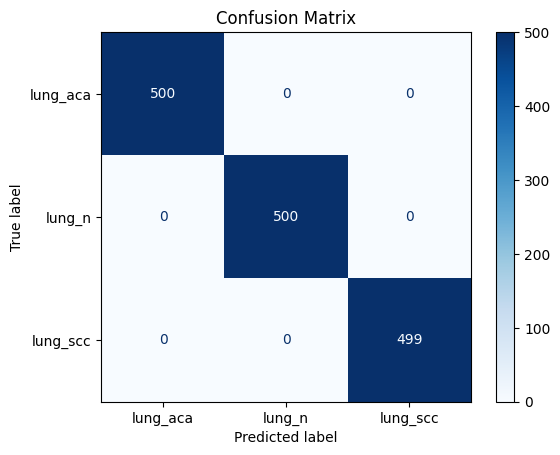

In [26]:
all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        labels_fixed = torch.tensor(
            [selected_classes.index(full_train_dataset.classes[l]) for l in labels]
        )

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels_fixed.numpy())

cm = confusion_matrix(all_labels, all_preds)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=selected_classes)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

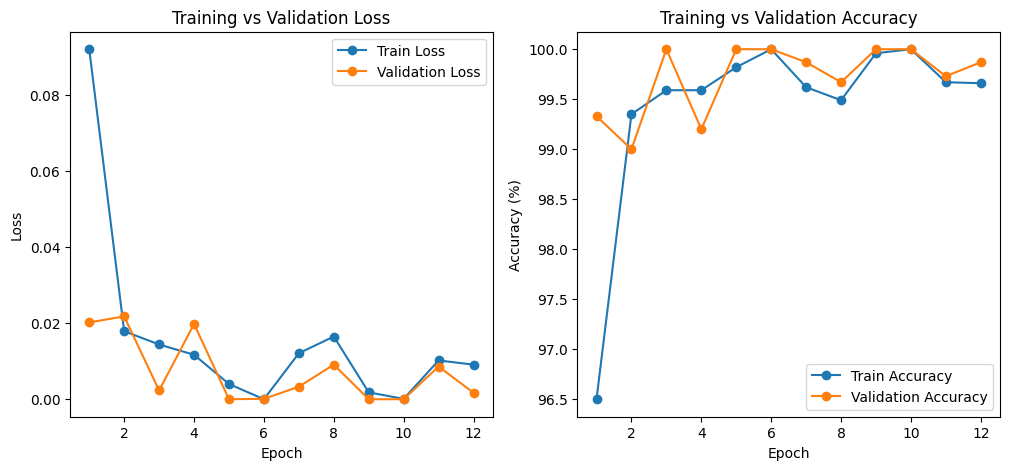

In [40]:
import matplotlib.pyplot as plt

# Data from your training logs
train_losses = [0.0921,0.0179,0.0144,0.0117,0.0040,0.0000,0.0121,0.0165,0.0018,0.0001,0.0102,0.0091]
val_losses   = [0.0202,0.0218,0.0023,0.0198,0.0000,0.0001,0.0033,0.0091,0.0000,0.0000,0.0086,0.0017]

train_accuracies = [96.50,99.35,99.59,99.59,99.82,100.00,99.62,99.49,99.96,100.00,99.67,99.66]
val_accuracies   = [99.33,99.00,100.00,99.20,100.00,100.00,99.87,99.67,100.00,100.00,99.73,99.87]

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12,5))

# Loss Curve
plt.subplot(1,2,1)
plt.plot(epochs, train_losses, marker='o', label="Train Loss")
plt.plot(epochs, val_losses, marker='o', label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# Accuracy Curve
plt.subplot(1,2,2)
plt.plot(epochs, train_accuracies, marker='o', label="Train Accuracy")
plt.plot(epochs, val_accuracies, marker='o', label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()